In [1]:
%%writefile /home/afzal/projects/knee-oa-classification/src/predict.py
"""Final inference pipeline: preprocess -> ensemble of two custom CNNs -> prior-adjusted decision.

Frozen before test-set evaluation. Members and decision rule chosen on validation data only.
"""
from pathlib import Path

import keras
import numpy as np

import data
import preprocessing as pp

PROJECT = Path.home() / "projects/knee-oa-classification"
MODELS = PROJECT / "models"
MEMBERS = ["exp1_augmentation", "exp3_aug_wider"]

TRAIN_COUNTS = np.array([2286, 1046, 1516, 757, 173])      # training images per KL grade
TRAIN_PRIOR = TRAIN_COUNTS / TRAIN_COUNTS.sum()


class KneeOAPipeline:
    def __init__(self, members=MEMBERS):
        self.members = list(members)
        self.models = [keras.models.load_model(MODELS / f"{m}.keras") for m in self.members]

    def predict_proba(self, X):
        """X: preprocessed uint8 images, shape (N, 224, 224). Returns averaged softmax (N, 5)."""
        ds = data.make_dataset(X, np.zeros(len(X), dtype=np.int64), batch_size=64)
        return np.mean([m.predict(ds, verbose=0) for m in self.models], axis=0)

    def predict(self, X, prior_adjust=True):
        p = self.predict_proba(X)
        return (p / TRAIN_PRIOR).argmax(axis=1) if prior_adjust else p.argmax(axis=1)

    def predict_image(self, path):
        """Full pipeline for one raw X-ray file: preprocess, predict, return grade + probabilities."""
        img = pp.load_and_preprocess(path)
        p = self.predict_proba(img[None])[0]
        adjusted = p / TRAIN_PRIOR
        return {"kl_grade": int(adjusted.argmax()),
                "model_probabilities": {g: round(float(v), 4) for g, v in enumerate(p)},
                "adjusted_scores": {g: round(float(v), 4) for g, v in enumerate(adjusted / adjusted.sum())}}

Writing /home/afzal/projects/knee-oa-classification/src/predict.py


In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import numpy as np
import pandas as pd

PROJECT = Path.home() / "projects/knee-oa-classification"
sys.path.insert(0, str(PROJECT / "src"))

import data
import evaluation as ev
from predict import KneeOAPipeline

pipe = KneeOAPipeline()
X_val, y_val = data.load_split("val")
m_val = ev.compute_metrics(y_val, pipe.predict(X_val))
print(f"Frozen pipeline on validation: balanced accuracy {m_val['balanced_accuracy']:.4f} "
      f"(expect 0.6467) | QWK {m_val['qwk']:.4f}")

I0000 00:00:1791134671.269579   24263 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791134671.303759   24263 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791134672.643351   24263 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791134674.577577   24263 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB mem

Frozen pipeline on validation: balanced accuracy 0.6467 (expect 0.6467) | QWK 0.7115


Test set: 1656 images | per grade [639 296 447 223  51]

Balanced accuracy: 0.6437 | Accuracy: 0.5417 | QWK: 0.7533 | Macro F1: 0.6036

              precision    recall  f1-score   support

           0      0.803     0.440     0.568       639
           1      0.237     0.436     0.307       296
           2      0.589     0.579     0.584       447
           3      0.713     0.803     0.755       223
           4      0.690     0.961     0.803        51

    accuracy                          0.542      1656
   macro avg      0.606     0.644     0.604      1656
weighted avg      0.628     0.542     0.558      1656



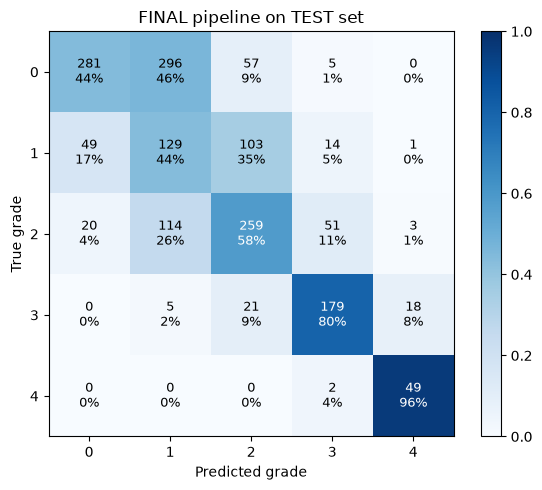


final (prior-adjusted)   bal_acc 0.644 [0.621, 0.666] | QWK 0.753 [0.730, 0.775] | recalls 0.44 / 0.44 / 0.58 / 0.80 / 0.96
secondary (argmax)       bal_acc 0.646 [0.621, 0.668] | QWK 0.756 [0.729, 0.780] | recalls 0.82 / 0.02 / 0.72 / 0.78 / 0.88
Validation reference (final pipeline): bal_acc 0.647 | QWK 0.711


In [3]:
from sklearn.metrics import balanced_accuracy_score, cohen_kappa_score

X_test, y_test = data.load_split("test")
print(f"Test set: {len(y_test)} images | per grade {np.bincount(y_test)}\n")

def bootstrap_ci(y_true, y_pred, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    ba, qwk = [], []
    for _ in range(n_boot):
        s = rng.integers(0, n, n)
        ba.append(balanced_accuracy_score(y_true[s], y_pred[s]))
        qwk.append(cohen_kappa_score(y_true[s], y_pred[s], weights="quadratic"))
    return np.percentile(ba, [2.5, 97.5]), np.percentile(qwk, [2.5, 97.5])

p_test = pipe.predict_proba(X_test)
decisions = {
    "final (prior-adjusted)": (p_test / pipe_prior).argmax(axis=1) if (pipe_prior := __import__("predict").TRAIN_PRIOR) is not None else None,
    "secondary (argmax)": p_test.argmax(axis=1),
}

# --- Primary result: full report ---
y_final = decisions["final (prior-adjusted)"]
m_test = ev.evaluate_predictions(y_test, y_final, title="FINAL pipeline on TEST set",
                                 save_path=PROJECT / "reports/cm_final_test.png")
ev.log_run("FINAL_ensemble_prior_adj", {"members": ["exp1_augmentation", "exp3_aug_wider"],
                                        "decision": "argmax(p / train_prior)"},
           m_test, split="test")

# --- Summary with confidence intervals, both decision rules ---
print("\n" + "=" * 92)
for name, pred in decisions.items():
    m = ev.compute_metrics(y_test, pred)
    (ba_lo, ba_hi), (q_lo, q_hi) = bootstrap_ci(y_test, pred)
    recalls = " / ".join(f"{m[f'recall_g{g}']:.2f}" for g in range(5))
    print(f"{name:24s} bal_acc {m['balanced_accuracy']:.3f} [{ba_lo:.3f}, {ba_hi:.3f}] | "
          f"QWK {m['qwk']:.3f} [{q_lo:.3f}, {q_hi:.3f}] | recalls {recalls}")
print("=" * 92)
print(f"Validation reference (final pipeline): bal_acc {m_val['balanced_accuracy']:.3f} | QWK {m_val['qwk']:.3f}")

In [ ]:
[